# Evaluation Metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

model = joblib.load("day3_model.pkl")
X_train = pd.read_csv("X_train_scaled.csv")
X_test = pd.read_csv("X_test_scaled.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Loaded model + splits. Test set size:", X_test.shape[0])

Loaded model + splits. Test set size: 1000


c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [ ]:
# Compute manually with numpy
# Writing the formulas out removes the "black box" feeling of sklearn.

def mae_manual(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse_manual(y_true, y_pred):
    return np.sqrt(mse_manual(y_true, y_pred))

def r2_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_total)

mae_m = mae_manual(y_test, y_pred_test)
mse_m = mse_manual(y_test, y_pred_test)
rmse_m = rmse_manual(y_test, y_pred_test)
r2_m = r2_manual(y_test, y_pred_test)

print(f"MAE  (manual): {mae_m:.4f}")
print(f"MSE  (manual): {mse_m:.4f}")
print(f"RMSE (manual): {rmse_m:.4f}")
print(f"R2   (manual): {r2_m:.4f}")

MAE  (manual): 0.7344
MSE  (manual): 0.8721
RMSE (manual): 0.9339
R2   (manual): 0.5697


In [3]:
# Compute via sklearn (must match manual)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_s = mean_absolute_error(y_test, y_pred_test)
mse_s = mean_squared_error(y_test, y_pred_test)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test, y_pred_test)

print(f"MAE  (sklearn): {mae_s:.4f}")
print(f"MSE  (sklearn): {mse_s:.4f}")
print(f"RMSE (sklearn): {rmse_s:.4f}")
print(f"R2   (sklearn): {r2_s:.4f}")

assert np.isclose(mae_m, mae_s) and np.isclose(mse_m, mse_s) and np.isclose(r2_m, r2_s)
print("\nManual and sklearn results match.")

MAE  (sklearn): 0.7344
MSE  (sklearn): 0.8721
RMSE (sklearn): 0.9339
R2   (sklearn): 0.5697

Manual and sklearn results match.


In [4]:
# Train vs Test comparison
# If train metrics are much better than test metrics → overfitting (model memorized train data, doesn't generalize).

results = pd.DataFrame({
    "metric": ["MAE", "MSE", "RMSE", "R2"],
    "train": [
        mean_absolute_error(y_train, y_pred_train),
        mean_squared_error(y_train, y_pred_train),
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        r2_score(y_train, y_pred_train),
    ],
    "test": [mae_s, mse_s, rmse_s, r2_s],
})
results

,metric,train,test
0,MAE,0.738099,0.734406
1,MSE,0.873926,0.872095
2,RMSE,0.934840,0.933860
3,R2,0.553439,0.569717


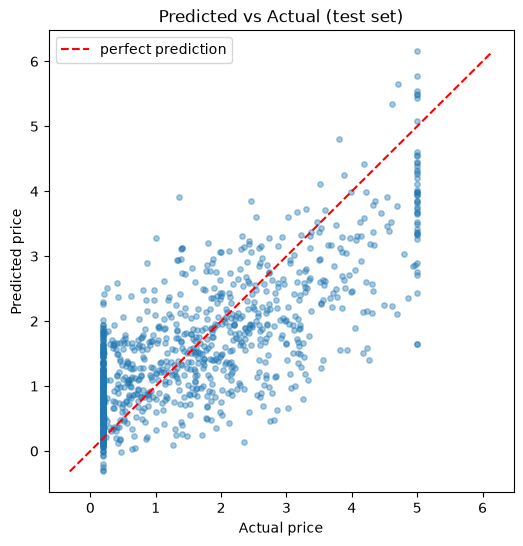

In [5]:
# Predicted vs Actual plot
# A single R² number can hide where the model fails. Visualize it.

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.4, s=15)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="perfect prediction")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Predicted vs Actual (test set)")
plt.legend()
plt.show()

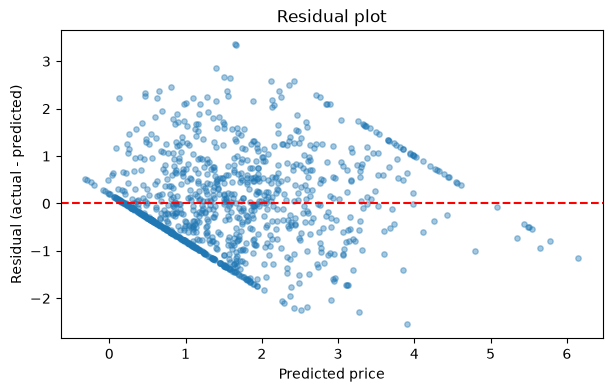

In [6]:
#  Residual plot

residuals = y_test - y_pred_test

plt.figure(figsize=(7,4))
plt.scatter(y_pred_test, residuals, alpha=0.4, s=15)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted price")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual plot")
plt.show()

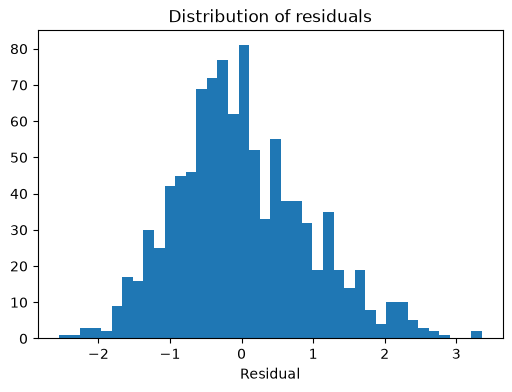

Residual mean (should be ~0): 0.0089
Residual std: 0.9343


In [7]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=40)
plt.title("Distribution of residuals")
plt.xlabel("Residual")
plt.show()

print("Residual mean (should be ~0):", residuals.mean().round(4))
print("Residual std:", residuals.std().round(4))

In [8]:
# Save final metrics for Day 5/6 write-up
results.to_csv("day4_metrics.csv", index=False)
print("Saved day4_metrics.csv")
print(results)

Saved day4_metrics.csv
  metric     train      test
0    MAE  0.738099  0.734406
1    MSE  0.873926  0.872095
2   RMSE  0.934840  0.933860
3     R2  0.553439  0.569717
